#**Василенко Иван ИБ N4170**

#**Методы оптимизации**

#**Задачи**

#Задача 1 ЛП

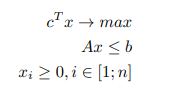

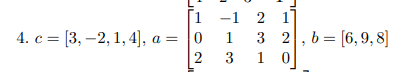

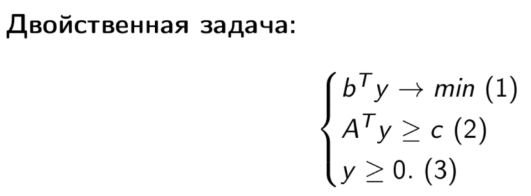

$ 6y_1 + 9y_2 + 8y_3 -> min $

При ограничениях:
- $ y_1 + 2y_3 \geq 3 $
- $ -y_1 + y_2 + 3y_3 \geq -2 $
- $ 2y_1 + 3y_2 + y_3 \geq 1 $
- $ y_1 + 2y_2 \geq 4 $
- $ y_1, y_2, y_3 \geq 0 $

In [ ]:
from fractions import Fraction

# Коэффициенты целевой функции с дополнительными переменными
c = [Fraction(3), Fraction(-2), Fraction(1), Fraction(4), Fraction(0), Fraction(0), Fraction(0)]

A = [
    [Fraction(1), Fraction(-1), Fraction(2), Fraction(1), Fraction(1), Fraction(0), Fraction(0)],
    [Fraction(0), Fraction(1), Fraction(3), Fraction(2), Fraction(0), Fraction(1), Fraction(0)],
    [Fraction(2), Fraction(3), Fraction(1), Fraction(0), Fraction(0), Fraction(0), Fraction(1)]
]

# Вектор правых частей b
b = [Fraction(6), Fraction(9), Fraction(8)]

# Количество переменных
n_vars = len(c)

# Количество ограничений
m = len(b)

# Начальный базис
B = [4, 5, 6]

# Коэффициенты целевой функции для базисных переменных
cb = [c[i] for i in B]

# Симплекс-таблица: каждая строка — индекс базисной переменной, cb_i, xb_i + коэффициенты A для всех переменных
table = []
for i in range(m):
    row = [B[i], cb[i], b[i]] + A[i]
    table.append(row)

reached = 0  # Флаг оптимальности
unbounded = 0  # Флаг неограниченности
alternate = 0  # Флаг альтернативных решений

while reached == 0:
    # Вычисление относительных прибылей: del_j = cj - sum(cb_i * a_ij), где a_ij — коэффициент в таблице
    rel_prof = []
    for j in range(n_vars):
        sum_zj = Fraction(0)
        for i in range(m):
            sum_zj += table[i][1] * table[i][3 + j]  # Формула: zj = sum(cb_i * a_ij)
        rel_prof.append(c[j] - sum_zj)  # del_j = cj - zj

    # Проверка на альтернативные решения (если для небазисной переменной del_j = 0)
    b_var = [row[0] for row in table]
    alternate = 0
    for j in range(n_vars):
        if j not in b_var and rel_prof[j] == 0:
            alternate = 1
            break

    # Проверка оптимальности: если все del_j ≤ 0 , то оптимально
    flag = 0
    for profit in rel_prof:
        if profit > 0:
            flag = 1
            break
    if flag == 0:
        reached = 1
        continue

    # Выбор входящей переменной k с максимальной del_j > 0
    k = -1
    max_prof = None
    for j in range(n_vars):
        if max_prof is None or rel_prof[j] > max_prof:
            max_prof = rel_prof[j]
            k = j

    # Тест минимального отношения: θ = min(xb_i / a_ik) для a_ik > 0, чтобы сохранить feasibility
    min_ = None
    r = -1
    for i in range(m):
        if table[i][3 + k] > 0:
            val = table[i][2] / table[i][3 + k]  # Формула: θ_i = xb_i / a_ik
            if r == -1 or val < min_:
                min_ = val
                r = i
    if r == -1:
        unbounded = 1  # Неограниченная задача
        break

    # Поворот: элемент pivot = a_rk
    pivot = table[r][3 + k]

    # Нормализация опорной строки: делим на pivot
    for col in range(2, len(table[0])):
        table[r][col] = table[r][col] / pivot  # Формула: новая строка r = старая строка r / pivot

    # Обновление других строк: вычитаем множитель * опорную строку
    for i in range(m):
        if i != r:
            multiplier = table[i][3 + k]  # Множитель = a_ik
            for col in range(2, len(table[0])):
                table[i][col] = table[i][col] - multiplier * table[r][col]  # Формула: новая строка i = старая i - multiplier * строка r

    # Обновление базиса: входящая переменная становится базисной
    table[r][0] = k
    table[r][1] = c[k]

# Результаты
if unbounded:
    print("Задача неограничена")
else:
    if alternate:
        print("Есть альтернативные решения")
    # Оптимальное значение z = ∑(cb_i * xb_i)
    opt_val = Fraction(0)
    for i in range(m):
        opt_val += table[i][1] * table[i][2]
    print("Оптимальное значение z:", str(opt_val))

    # Значения переменных
    solutions = [Fraction(0) for _ in range(n_vars)]
    for i in range(m):
        var = table[i][0]
        solutions[var] = table[i][2]
    print("Решение (x1, x2, x3, x4, s1, s2, s3):", [str(s) for s in solutions])

    # Для двойственной: y_i = - del_j
    rel_prof = []
    for j in range(n_vars):
        sum_zj = Fraction(0)
        for i in range(m):
            sum_zj += table[i][1] * table[i][3 + j]
        rel_prof.append(c[j] - sum_zj)
    y = [-rel_prof[4], -rel_prof[5], -rel_prof[6]]
    print("Решение двойственной (y1, y2, y3):", [str(yy) for yy in y])

Оптимальное значение z: 275/12
Решение (x1, x2, x3, x4, s1, s2, s3): ['11/4', '5/6', '0', '49/12', '0', '0', '0']
Решение двойственной (y1, y2, y3): ['17/6', '7/12', '1/12']


#Задача 2 Многокритериальная оптимизация
Уступка по первому критерию оптимизации 10%

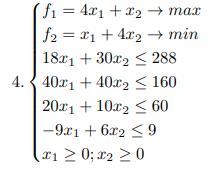

In [ ]:
from fractions import Fraction

def simplex_method(c, A, b, is_max=True, extra_constraints=None):
    """
    Симплекс-метод с two-phase для обработки negative b.
    """
    if extra_constraints:
        A_extra, b_extra = extra_constraints
        A = A + A_extra
        b = b + b_extra

    A = [list(row) for row in A]
    b = list(b)
    m = len(b)
    n = len(c)

    # Нормализация: flip rows с b < 0
    slack_signs = [1] * m
    artificials = [False] * m
    for i in range(m):
        if b[i] < 0:
            A[i] = [-a for a in A[i]]
            b[i] = -b[i]
            slack_signs[i] = -1
            artificials[i] = True

    num_art = sum(artificials)
    if num_art == 0:
        # Нет artificial, стандартный симплекс
        if not is_max:
            c = [-ci for ci in c]
        c_ext = [Fraction(ci) for ci in c] + [Fraction(0)] * m
        A_ext = []
        for i in range(m):
            row = [Fraction(aij) for aij in A[i]] + [Fraction(0)] * m
            row[n + i] = Fraction(slack_signs[i])  # Хотя здесь все +1
            A_ext.append(row)
        b = [Fraction(bb) for bb in b]
        n_vars = n + m
        basis = list(range(n, n_vars))
        cb = [c_ext[i] for i in basis]
        table = []
        for i in range(m):
            table.append([basis[i], cb[i], b[i]] + A_ext[i])
        # Run simplex
        reached = 0
        unbounded = 0
        iterations = 0
        while reached == 0 and iterations < 100:
            iterations += 1
            rel_prof = []
            for j in range(n_vars):
                zj = sum(table[ii][1] * table[ii][3 + j] for ii in range(m))
                rel_prof.append(c_ext[j] - zj)
            if all(rp <= 0 for rp in rel_prof):
                reached = 1
                continue
            k = 0
            max_rp = rel_prof[0]
            for jj in range(1, n_vars):
                if rel_prof[jj] > max_rp:
                    max_rp = rel_prof[jj]
                    k = jj
            min_ratio = None
            r = -1
            for ii in range(m):
                aik = table[ii][3 + k]
                if aik > 0:
                    ratio = table[ii][2] / aik
                    if min_ratio is None or ratio < min_ratio:
                        min_ratio = ratio
                        r = ii
            if r == -1:
                unbounded = 1
                break
            pivot = table[r][3 + k]
            for col in range(2, len(table[0])):
                table[r][col] /= pivot
            for ii in range(m):
                if ii != r:
                    mult = table[ii][3 + k]
                    for col in range(2, len(table[0])):
                        table[ii][col] -= mult * table[r][col]
            table[r][0] = k
            table[r][1] = c_ext[k]
        if unbounded:
            return "Unbounded", None, None
        if not reached:
            return "No convergence", None, None
        opt_val = sum(table[ii][1] * table[ii][2] for ii in range(m))
        if not is_max:
            opt_val = -opt_val
        x = [Fraction(0)] * n
        for ii in range(m):
            var = table[ii][0]
            if var < n:
                x[var] = table[ii][2]
        return opt_val, x, table
    else:
        # Two-phase
        total_vars = n + m + num_art
        art_map = {}
        k = 0
        for i in range(m):
            if artificials[i]:
                art_map[i] = n + m + k
                k += 1
        c_phase1 = [Fraction(0)] * (n + m) + [Fraction(-1)] * num_art
        A_ext = []
        for i in range(m):
            row = [Fraction(a) for a in A[i]] + [Fraction(0)] * m + [Fraction(0)] * num_art
            row[n + i] = Fraction(slack_signs[i])
            if i in art_map:
                row[art_map[i]] = Fraction(1)
            A_ext.append(row)
        b = [Fraction(bb) for bb in b]
        basis = [-1] * m
        for i in range(m):
            if artificials[i]:
                basis[i] = art_map[i]
            else:
                basis[i] = n + i
        table = []
        for i in range(m):
            table.append([basis[i], c_phase1[basis[i]], b[i]] + A_ext[i])
        def run_simplex(table, c_ext, m, n_vars):
            reached = 0
            unbounded = 0
            iterations = 0
            while reached == 0 and iterations < 100:
                iterations += 1
                rel_prof = []
                for j in range(n_vars):
                    zj = sum(table[ii][1] * table[ii][3 + j] for ii in range(m))
                    rel_prof.append(c_ext[j] - zj)
                if all(rp <= 0 for rp in rel_prof):
                    reached = 1
                    continue
                k = 0
                max_rp = rel_prof[0]
                for jj in range(1, n_vars):
                    if rel_prof[jj] > max_rp:
                        max_rp = rel_prof[jj]
                        k = jj
                min_ratio = None
                r = -1
                for ii in range(m):
                    aik = table[ii][3 + k]
                    if aik > 0:
                        ratio = table[ii][2] / aik
                        if min_ratio is None or ratio < min_ratio:
                            min_ratio = ratio
                            r = ii
                if r == -1:
                    unbounded = 1
                    break
                pivot = table[r][3 + k]
                for col in range(2, len(table[0])):
                    table[r][col] /= pivot
                for ii in range(m):
                    if ii != r:
                        mult = table[ii][3 + k]
                        for col in range(2, len(table[0])):
                            table[ii][col] -= mult * table[r][col]
                table[r][0] = k
                table[r][1] = c_ext[k]
            if unbounded:
                return "Unbounded", None, 0
            opt_val = sum(table[ii][1] * table[ii][2] for ii in range(m))
            return opt_val, table, reached
        # Phase 1
        opt_phase1, table, reached = run_simplex(table, c_phase1, m, total_vars)
        if not reached or opt_phase1 != Fraction(0):
            return "Infeasible", None, None
        # Phase 2
        orig_c = c if is_max else [-cc for cc in c]
        c_ext2 = [Fraction(cc) for cc in orig_c] + [Fraction(0)] * m
        total_vars2 = n + m
        for row in table:
            del row[3 + total_vars2 :]
        for i in range(m):
            table[i][1] = c_ext2[table[i][0]]
        opt_phase2, table, reached = run_simplex(table, c_ext2, m, total_vars2)
        if not reached:
            return "No convergence", None, None
        opt_val = opt_phase2
        if not is_max:
            opt_val = -opt_val
        x = [Fraction(0)] * n
        for ii in range(m):
            var = table[ii][0]
            if var < n:
                x[var] = table[ii][2]
        return opt_val, x, table

# Коэффициенты
A = [[18, 30], [40, 40], [20, 10], [-9, 6]]
b = [288, 160, 60, 9]

# 1. Max f1 = 4x1 + x2
c_f1 = [4, 1]
f1_star, x_f1, _ = simplex_method(c_f1, A, b, is_max=True)
print(f"Индивидуальный оптимум f1*: {f1_star} в точке x = {x_f1}")

# 2. Min f2 = x1 + 4x2
c_f2 = [1, 4]
f2_star, x_f2, _ = simplex_method(c_f2, A, b, is_max=False)
print(f"Индивидуальный оптимум f2*: {f2_star} в точке x = {x_f2}")

# 3. Метод уступок: min f2 с f1 >= 0.9 * f1*
constr_f1 = Fraction(9,10) * f1_star
A_extra = [[-4, -1]]  # - (4x1 + x2) <= -constr_f1
b_extra = [-constr_f1]
f2_opt, x_opt, _ = simplex_method(c_f2, A, b, is_max=False, extra_constraints=(A_extra, b_extra))
f1_opt = Fraction(4) * x_opt[0] + x_opt[1]  # Проверяем f1 в оптимальной точке

print(f"Оптимальное по методу уступок: f2 = {f2_opt}, f1 = {f1_opt} в точке x = {x_opt}")

Индивидуальный оптимум f1*: 12 в точке x = [Fraction(3, 1), Fraction(0, 1)]
Индивидуальный оптимум f2*: 0 в точке x = [Fraction(0, 1), Fraction(0, 1)]
Оптимальное по методу уступок: f2 = 27/10, f1 = 54/5 в точке x = [Fraction(27, 10), Fraction(0, 1)]


#Задача 5 метод ветвей и границ

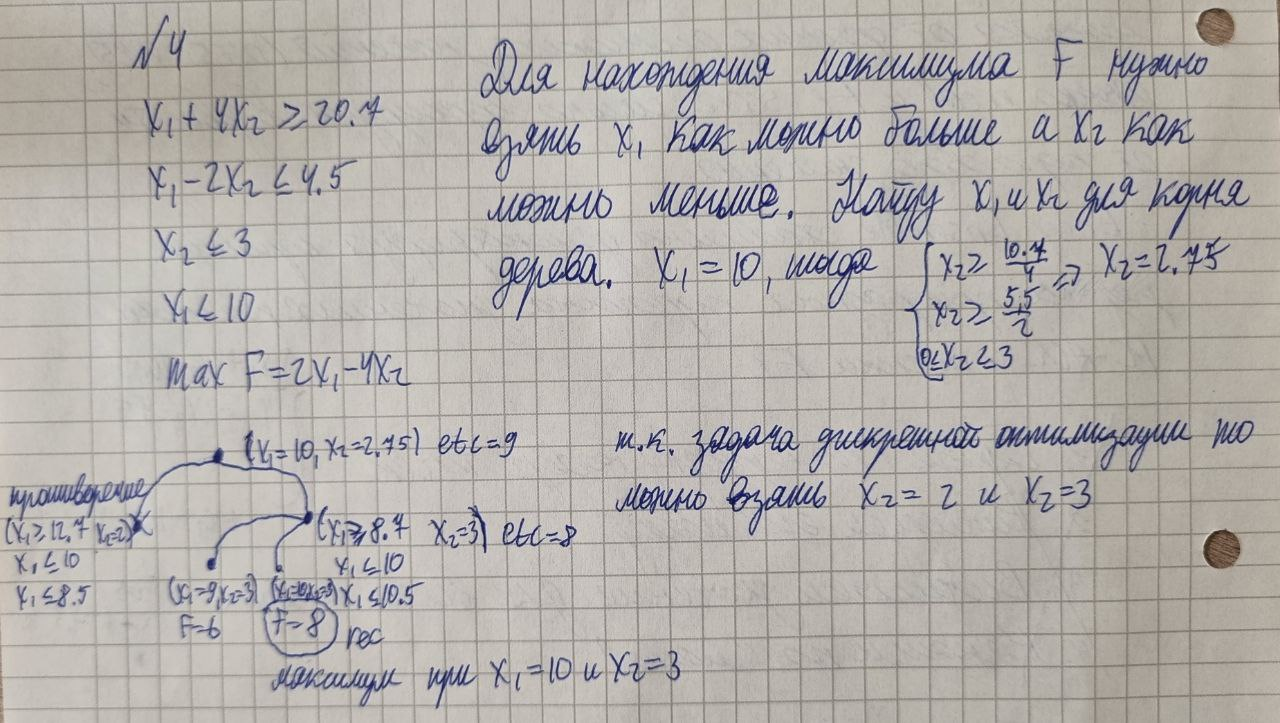